<a href="https://colab.research.google.com/github/fcoliveira-utfpr/climate_parana/blob/main/comparison_with_classical_climate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Start – Libraries
---

In [1]:
# =========================================================
# REQUIRED LIBRARIES
# =========================================================
!pip install geobr geopandas rasterio elevation cartopy matplotlib-scalebar --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import geobr
from geobr import read_municipality
from matplotlib.colors import ListedColormap

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from matplotlib.lines import Line2D


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 75.2 MB/s eta 0:00:00


#Mapas de ZCs

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


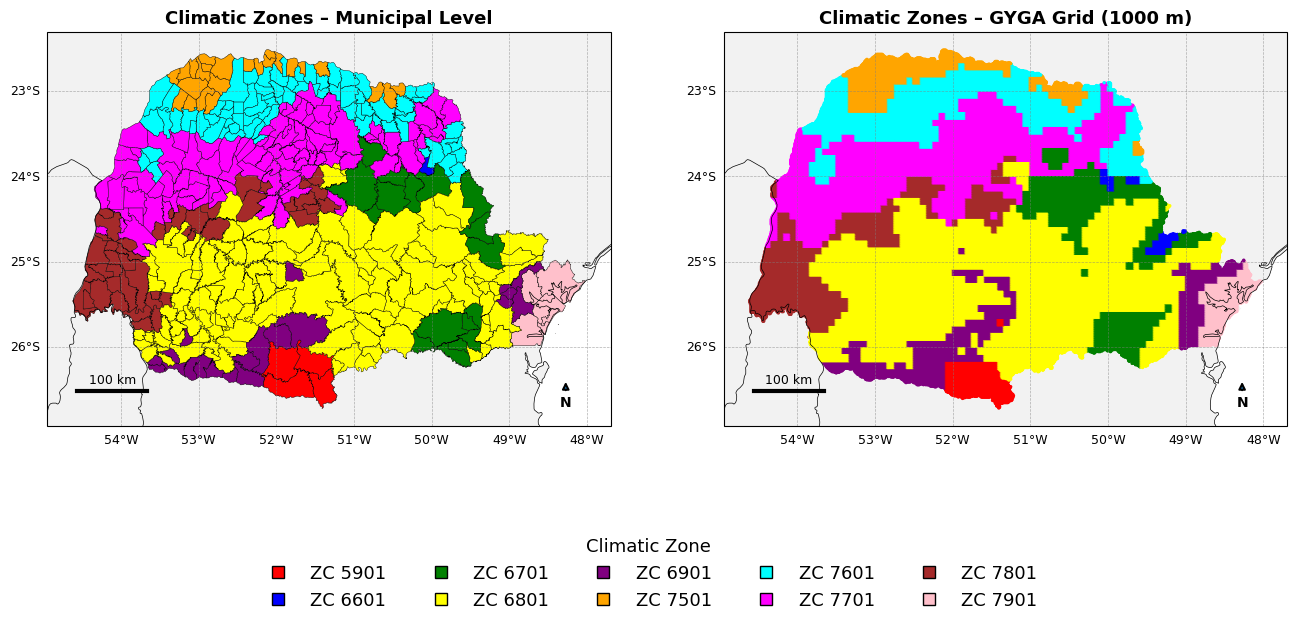

In [2]:
# =========================================================
# DATA – LEFT MAP (MUNICIPAL CLIMATIC ZONES)
# =========================================================
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/climate_parana/refs/heads/main/dados_concatenados_zc.csv"
df = pd.read_csv(url, sep=",")

df['variavel'] = df['variavel'].str.lower()

# Pivot to structured municipal dataset
df_clima = (
    df.pivot_table(
        index=['estado', 'municipio', 'lat', 'lon', 'ZC'],
        columns='variavel',
        values='valor',
        aggfunc='mean'
    )
    .reset_index()
)

# =========================================================
# LOAD MUNICIPAL GEOMETRY – PARANÁ
# =========================================================
mun_pr = read_municipality(code_muni="PR", year=2020)

mun_pr['municipio'] = (
    mun_pr['name_muni']
    .str.upper()
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
)

mun_pr = mun_pr.to_crs(epsg=4674)

# Merge climatic zones with municipal boundaries
gdf_mun = mun_pr.merge(
    df_clima[['municipio', 'ZC']].drop_duplicates(),
    on='municipio',
    how='left'
)

# =========================================================
# COLOR PALETTE – CLIMATIC ZONES
# =========================================================
zc_palette = {
    5901: '#FF0000',
    6601: '#0000FF',
    6701: '#008000',
    6801: '#FFFF00',
    6901: '#800080',
    7501: '#FFA500',
    7601: '#00FFFF',
    7701: '#FF00FF',
    7801: '#A52A2A',
    7901: '#FFC0CB',
    #8001: '#00FF00',
    #8101: '#008080'
}

gdf_mun['color'] = gdf_mun['ZC'].map(zc_palette).fillna('#D9D9D9')

# =========================================================
# LOAD GYGA POINT DATA
# =========================================================
url = "https://github.com/fcoliveira-utfpr/climate_parana/releases/download/v3.0/GYGA_CZ_original_PR_1000m.csv"
df45 = pd.read_csv(url, sep=",")

cz_palette = zc_palette
zc_validas = set(cz_palette.keys())

# Convert CSV to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df45,
    geometry=gpd.points_from_xy(df45['lon'], df45['lat']),
    crs='EPSG:4326'
)

# Reproject to metric CRS for spatial correction
gdf = gdf.to_crs(epsg=5880)

# Separate valid and invalid zones
gdf_validos = gdf[gdf['GYGA_CZ'].isin(zc_validas)]
gdf_invalidos = gdf[~gdf['GYGA_CZ'].isin(zc_validas)]

# Nearest neighbor spatial correction
gdf_corrigido = gpd.sjoin_nearest(
    gdf_invalidos,
    gdf_validos[['GYGA_CZ', 'geometry']],
    how='left'
)

df45.loc[gdf_corrigido.index, 'GYGA_CZ'] = gdf_corrigido['GYGA_CZ_right']

# =========================================================
# CREATE MULTIPANEL FIGURE
# =========================================================
fig = plt.figure(figsize=(16, 8))

# =========================================================
# LEFT MAP – MUNICIPAL CLIMATIC ZONES
# =========================================================
ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())

minx, miny, maxx, maxy = gdf_mun.total_bounds
dx = (maxx - minx) * 0.05
dy = (maxy - miny) * 0.05

ax1.set_extent(
    [minx - dx, maxx + dx, miny - dy, maxy + dy],
    crs=ccrs.PlateCarree()
)

# Add cartographic base layers
ax1.add_feature(cfeature.LAND, facecolor='#F2F2F2')
ax1.add_feature(cfeature.BORDERS, linewidth=0.5)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)

# Add gridlines
gl = ax1.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.6,
    linestyle='--'
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 9}
gl.ylabel_style = {'size': 9}

# Plot municipalities
gdf_mun.plot(
    ax=ax1,
    color=gdf_mun['color'],
    edgecolor='black',
    linewidth=0.3,
    transform=ccrs.PlateCarree()
)

ax1.set_title('Climatic Zones – Municipal Level', fontsize=13, fontweight='bold')

# =========================================================
# SCALE BAR (100 km)
# =========================================================
def add_scalebar(ax, gdf_bounds, length_km=100):

    minx, miny, maxx, maxy = gdf_bounds

    length_deg = length_km / 111  # Approximate conversion

    x_start = minx + (maxx - minx) * 0.009
    y_start = miny + (maxy - miny) * 0.05

    ax.plot(
        [x_start, x_start + length_deg],
        [y_start, y_start],
        transform=ccrs.PlateCarree(),
        color='black',
        linewidth=3
    )

    ax.text(
        x_start + length_deg / 2,
        y_start + (maxy - miny) * 0.02,
        f'{length_km} km',
        transform=ccrs.PlateCarree(),
        ha='center',
        fontsize=9
    )

# =========================================================
# NORTH ARROW – LOWER RIGHT
# =========================================================
ax1.annotate(
    'N',
    xy=(0.92, 0.12),
    xytext=(0.92, 0.06),
    xycoords='axes fraction',
    textcoords='axes fraction',
    ha='center',
    va='center',
    fontsize=10,
    fontweight='bold',
    arrowprops=dict(arrowstyle='-|>', linewidth=1.5)
)

# =========================================================
# RIGHT MAP – GYGA POINTS
# =========================================================
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())

ax2.set_extent(
    [minx - dx, maxx + dx, miny - dy, maxy + dy],
    crs=ccrs.PlateCarree()
)

ax2.add_feature(cfeature.LAND, facecolor='#F2F2F2')
ax2.add_feature(cfeature.BORDERS, linewidth=0.5)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)

gl2 = ax2.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.6,
    linestyle='--'
)

gl2.top_labels = False
gl2.right_labels = False
gl2.xlabel_style = {'size': 9}
gl2.ylabel_style = {'size': 9}

gdf_plot = gpd.GeoDataFrame(
    df45,
    geometry=gpd.points_from_xy(df45['lon'], df45['lat']),
    crs='EPSG:4326'
)

gdf_plot['color'] = gdf_plot['GYGA_CZ'].map(cz_palette).fillna('#D9D9D9')

gdf_plot.plot(
    ax=ax2,
    color=gdf_plot['color'],
    markersize=2,
    transform=ccrs.PlateCarree()
)

ax2.set_title('Climatic Zones – GYGA Grid (1000 m)', fontsize=13, fontweight='bold')

# North arrow – lower right
ax2.annotate(
    'N',
    xy=(0.92, 0.12),
    xytext=(0.92, 0.06),
    xycoords='axes fraction',
    textcoords='axes fraction',
    ha='center',
    va='center',
    fontsize=10,
    fontweight='bold',
    arrowprops=dict(arrowstyle='-|>', linewidth=1.5)
)

# =========================================================
# SHARED LEGEND
# =========================================================
legend_elements = [
    Line2D([0], [0], marker='s', linestyle='none',
           label=f'ZC {k}', markerfacecolor=v,
           markeredgecolor='black', markersize=8)
    for k, v in zc_palette.items()
]

fig.legend(
    handles=legend_elements,
    title='Climatic Zone',
    loc='lower center',
    ncol=5,
    frameon=False,
    fontsize=13,
    title_fontsize=13
)

add_scalebar(ax1, gdf_mun.total_bounds, 100)
add_scalebar(ax2, gdf_mun.total_bounds, 100)

# ---------------------------------------------------------
# EXPORT
# ---------------------------------------------------------
plt.savefig("Figure2.png", dpi=600, bbox_inches='tight')
plt.show()


#Maps of comparison
---

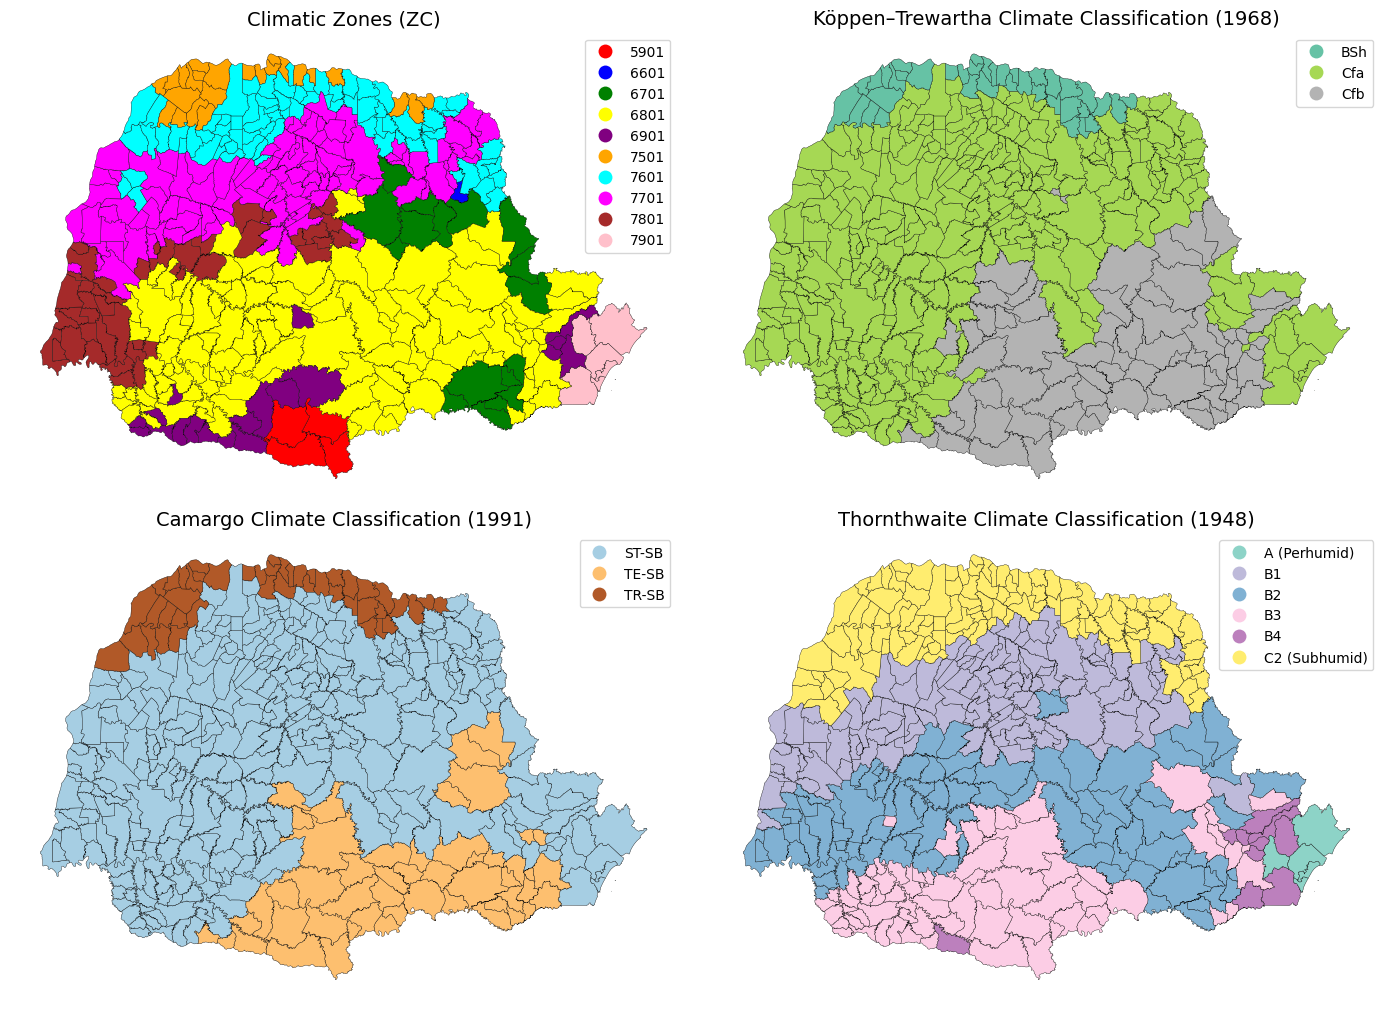

In [4]:
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/climate_parana/refs/heads/main/pr_classificacoes_climaticas_1991_2020_centroide.csv"
df_cls = pd.read_csv(url, sep=",")

# ---------------------------------------------------------
# STANDARDIZE MUNICIPALITY NAMES
# ---------------------------------------------------------
df_cls['municipio'] = (
    df_cls['municipio']
    .str.upper()
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
)

# Replace missing climatic zones and remove decimal artifacts
df_cls['ZC'] = df_cls['ZC'].fillna('No ZC').astype(str)
df_cls['ZC'] = df_cls['ZC'].apply(
    lambda x: x.replace('.0', '') if x != 'No ZC' else x
)

# ---------------------------------------------------------
# GEOGRAPHIC BASE – MUNICIPALITIES OF PARANÁ
# ---------------------------------------------------------
mun_pr = read_municipality(code_muni="PR", year=2020)

mun_pr['municipio'] = (
    mun_pr['name_muni']
    .str.upper()
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
)

# Set CRS to SIRGAS 2000
mun_pr = mun_pr.to_crs(epsg=4674)

# ---------------------------------------------------------
# MERGE CLIMATIC CLASSIFICATIONS WITH MUNICIPAL GEOMETRY
# ---------------------------------------------------------
gdf = mun_pr.merge(df_cls, on='municipio', how='left')

# Standardize Camargo classification names
gdf['CM_nome'] = (
    gdf['CM_nome']
    .astype(str)
    .str.strip()
    .str.replace('–','-')
)

# Fill missing classification values
for col_name in ['ZC', 'KT_nome', 'CM_nome', 'TH_nome']:
    if col_name in gdf.columns:
        gdf[col_name] = gdf[col_name].fillna('No Data')

# ---------------------------------------------------------
# TRANSLATION DICTIONARIES (PORTUGUESE → ENGLISH)
# ---------------------------------------------------------

# Comprehensive dictionary for Thornthwaite individual terms
individual_thornthwaite_terms = {
    'Subúmido seco': 'Dry Subhumid',
    'Subúmido úmido': 'Moist Subhumid',
    'Úmido': 'Humid',
    'Superúmido': 'Perhumid',
    'Semiárido': 'Semi-arid',
    'Árido': 'Arid',
    'Subúmido': 'Subhumid' # Add this for terms like 'C2 (Subúmido)'
}

def comprehensive_thornthwaite_translation(text):
    if pd.isna(text) or text == 'No Data':
        return 'No Data'
    translated_text = str(text)
    # Sort terms by length in descending order to ensure longer phrases are replaced first
    sorted_terms = sorted(individual_thornthwaite_terms.items(), key=lambda item: len(item[0]), reverse=True)
    for pt, en in sorted_terms:
        translated_text = translated_text.replace(pt, en)
    return translated_text


camargo_translation = {
    'Tropical úmido': 'Humid Tropical',
    'Tropical subúmido': 'Subhumid Tropical',
    'Subtropical úmido': 'Humid Subtropical',
    'Subtropical': 'Subtropical',
    'Temperado': 'Temperate'
}

koppen_translation = {
    'Tropical chuvoso': 'Rainy Tropical',
    'Subtropical úmido': 'Humid Subtropical',
    'Temperado': 'Temperate',
    'Tropical': 'Tropical'
}

# ---------------------------------------------------------
# CREATE ENGLISH CLASSIFICATION COLUMNS
# ---------------------------------------------------------

gdf['TH_name'] = gdf['TH_nome'].apply(comprehensive_thornthwaite_translation)
gdf['CM_name'] = gdf['CM_nome'].map(camargo_translation).fillna(gdf['CM_nome'])
gdf['KT_name'] = gdf['KT_nome'].map(koppen_translation).fillna(gdf['KT_nome'])

# ---------------------------------------------------------
# CUSTOM COLOR PALETTE FOR CLIMATIC ZONES (ZC)
# ---------------------------------------------------------
zc_palette = {
    '5901': '#FF0000',
    '6601': '#0000FF',
    '6701': '#008000',
    '6801': '#FFFF00',
    '6901': '#800080',
    '7501': '#FFA500',
    '7601': '#00FFFF',
    '7701': '#FF00FF',
    '7801': '#A52A2A',
    '7901': '#FFC0CB',
    '8001': '#00FF00',
    '8101': '#008080'
}

zc_categories = sorted(gdf['ZC'].unique())

zc_colors = [
    zc_palette.get(cat, '#D3D3D3')
    for cat in zc_categories
]

zc_cmap = ListedColormap(zc_colors)

# ---------------------------------------------------------
# MULTIPANEL MAP (USING ENGLISH CLASSIFICATIONS)
# ---------------------------------------------------------
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10),
    constrained_layout=True
)

plots = [
    ('ZC', 'Climatic Zones (ZC)', zc_cmap),
    ('KT_name', 'Köppen–Trewartha Climate Classification (1968)', 'Set2'),
    ('CM_name', 'Camargo Climate Classification (1991)', 'Paired'),
    ('TH_name', 'Thornthwaite Climate Classification (1948)', 'Set3')
]

for ax, (col, title, cmap) in zip(axes.flatten(), plots):

    if col == 'ZC':
        gdf.plot(
            column=col,
            categorical=True,
            categories=zc_categories,
            legend=True,
            cmap=cmap,
            linewidth=0.25,
            edgecolor='black',
            ax=ax
        )
    else:
        gdf.plot(
            column=col,
            categorical=True,
            legend=True,
            cmap=cmap,
            linewidth=0.25,
            edgecolor='black',
            ax=ax
        )

    ax.set_title(title, fontsize=14)
    ax.set_axis_off()

# ---------------------------------------------------------
# EXPORT
# ---------------------------------------------------------
plt.savefig("Figure8.png", dpi=600, bbox_inches='tight')
plt.show()

#Statisticals

In [5]:
tab_zc_kt = pd.crosstab(df_cls['ZC'], df_cls['KT'])
tab_zc_cm = pd.crosstab(df_cls['ZC'], df_cls['CM'])
tab_zc_cm = pd.crosstab(df_cls['ZC'], df_cls['CM'])
def classe_predominante(series):
    return series.value_counts().idxmax()

resumo_zc = (
    df_cls
    .groupby('ZC')
    .agg(
        KT_pred=('KT', classe_predominante),
        CM_pred=('CM', classe_predominante),
        TH_pred=('TH', classe_predominante)
    )
    .reset_index()
)

resumo_zc

,ZC,KT_pred,CM_pred,TH_pred
0,5901,6.0,44.0,3.0
1,6601,5.0,54.0,5.0
2,6701,5.0,54.0,4.0
3,6801,5.0,54.0,4.0
4,6901,6.0,54.0,3.0
5,7501,3.0,64.0,6.0
6,7601,5.0,54.0,6.0
7,7701,5.0,54.0,5.0
8,7801,5.0,54.0,4.0
9,7901,5.0,54.0,1.0


In [7]:
def concordancia(zc, sistema):
    tab = pd.crosstab(df_cls['ZC'], df_cls[sistema])
    return (tab.max(axis=1) / tab.sum(axis=1) * 100).round(1)

concord_kt = concordancia(df_cls['ZC'], 'KT')
concord_cm = concordancia(df_cls['ZC'], 'CM')
concord_th = concordancia(df_cls['ZC'], 'TH')

dfr = pd.DataFrame({
    'ZC': concord_kt.index,
    'KT_%': concord_kt.values,
    'CM_%': concord_cm.values,
    'TH_%': concord_th.values
})
dfr

,ZC,KT_%,CM_%,TH_%
0,5901,100.0,100.0,100.0
1,6601,100.0,100.0,100.0
2,6701,52.9,58.8,52.9
3,6801,56.4,71.8,50.9
4,6901,52.6,57.9,73.7
5,7501,87.5,91.7,100.0
6,7601,77.6,71.1,93.4
7,7701,100.0,99.0,86.7
8,7801,100.0,100.0,50.0
9,7901,100.0,100.0,66.7
